### 11.4 Importing libraries


In [1]:
import rasterio
import rasterio.plot
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
raster_path = './Drone_Orthomosaics/Orthos2023_09/Altum/Altum_1/Orthomosaic/Altum_1_transparent_mosaic_blue.tif'
src = rasterio.open(raster_path)
print(src)

<open DatasetReader name='./Drone_Orthomosaics/Orthos2023_09/Altum/Altum_1/Orthomosaic/Altum_1_transparent_mosaic_blue.tif' mode='r'>


1.**File Name**

In [3]:
src.name

'./Drone_Orthomosaics/Orthos2023_09/Altum/Altum_1/Orthomosaic/Altum_1_transparent_mosaic_blue.tif'

In [4]:
src.mode

'r'

In [5]:
src.meta

{'driver': 'GTiff',
 'dtype': 'uint16',
 'nodata': None,
 'width': 10093,
 'height': 8787,
 'count': 2,
 'crs': CRS.from_epsg(32648),
 'transform': Affine(0.026670000000000003, 0.0, 563446.3083700001,
        0.0, -0.026670000000000003, 5266763.1487300005)}

### 11.6.2 Coordinate Reference System (CRS)
The CRS expresses the location (latitude and longitude or projected coordinates(which represents Earth's curved surface on a flat plane. This is achieved using map projection.))

In [6]:
src.crs

CRS.from_epsg(32648)

In [7]:
# Spatial resolution : size of one pixel in real-world units
src.res

(0.026670000000000003, 0.026670000000000003)

In [8]:
src.width, src.height

(10093, 8787)

In [9]:
src.shape

(8787, 10093)

In [10]:
# Bounds: the spatial extent of the raster (left, bottom, right, top)
src.bounds

BoundingBox(left=563446.3083700001, bottom=5266528.79944, right=563715.4886800001, top=5266763.1487300005)

In [11]:
src.dtypes

('uint16', 'uint16')

### 11.6.7 Affine Transform
Maps pixel coordinates to geographic coordinates.


In [12]:
src.transform

Affine(0.026670000000000003, 0.0, 563446.3083700001,
       0.0, -0.026670000000000003, 5266763.1487300005)

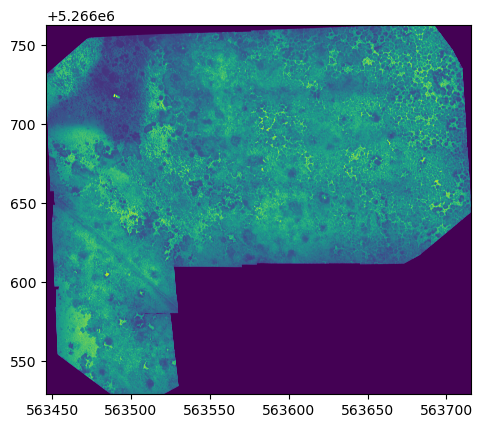

<Axes: >

In [13]:
rasterio.plot.show(src)

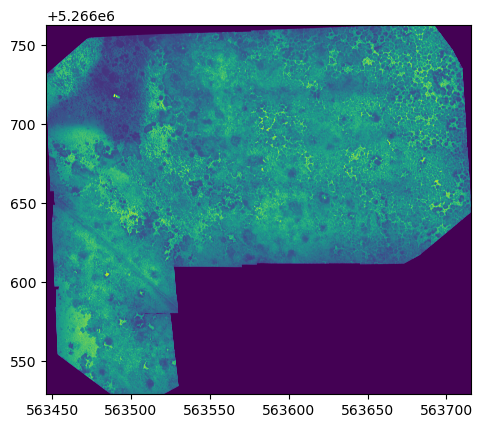

<Axes: >

In [17]:
rasterio.plot.show((src, 1))

### 11.8.1 Reading Multiple Bands

In [18]:
raster_path = './Drone_Orthomosaics/Orthos2024_10/DJI_P4_MS/Bad_10/Bad_2024_10_P4_MS.tif'
src = rasterio.open(raster_path)
print(src)

<open DatasetReader name='./Drone_Orthomosaics/Orthos2024_10/DJI_P4_MS/Bad_10/Bad_2024_10_P4_MS.tif' mode='r'>


In [19]:
src.meta

{'driver': 'GTiff',
 'dtype': 'float32',
 'nodata': None,
 'width': 7758,
 'height': 11814,
 'count': 6,
 'crs': CRS.from_epsg(32648),
 'transform': Affine(0.02499824387514935, 0.0, 571070.642244922,
        0.0, -0.024998549465452664, 5274821.18268412)}

This dataset contains multiple bands, each corresponding to a specific wavelength range (DJI_P4_MS):
| Name | Wavelength | Description |
|----------|----------|----------|
| Red |  650 nm ± 16 nm | Row 1 Col 3 |
| Green |  560 nm ± 16 nm | Row 2 Col 3 |
| Blue |  450 nm ± 16 nm | Row 3 Col 3 |
| Red_Edge | 730 nm ± 16 nm | Row 4 Col 3 |
| Near-infrared | 840 nm ± 26 nm | Row 5 Col 3 |

band_names = ["]